#Import Libraries

In [65]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix


from sklearn.svm import SVC


from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score


We imported the required libraries for data analysis and visualization.

#Reading Dataset

In [66]:
data=pd.read_csv("hotel_booking.csv")
df=data.copy()
display(df.head(20))
print(f"Dataset shape: {df.shape}")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Transient,107.00,0,0,Check-Out,2015-07-03,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,Transient,103.00,0,1,Check-Out,2015-07-03,William Velez,Velez_William@mail.com,286-669-4333,************8729
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,Transient,82.00,0,1,Canceled,2015-05-06,Steven Murphy,Steven.Murphy54@aol.com,341-726-5787,************3639
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,Transient,105.50,0,0,Canceled,2015-04-22,Michael Moore,MichaelMoore81@outlook.com,316-648-6176,************9190


Dataset shape: (119390, 36)


We loaded the dataset and displayed its shape to understand the number of rows and columns.

#Data Understanding

In [67]:
data_info=df.info()
data_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

we checked the dataset information including column names, data types, and non-null values.

#Data Quality Check

In [68]:
data_na = df.isna().sum()
data_na

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


We checked for columns that have nan values and found nan values in 'children' , 'country' , 'agent' , 'company'

In [69]:
full_duplicates = df.duplicated().sum()
full_duplicates

np.int64(0)

we checked for duplication and found no duplications

In [70]:
df["company"] = df["company"].fillna(0)

In [71]:
df["agent"] = df["agent"].fillna(0)

In [72]:
df["country"] = df["country"].fillna(
    df["country"].mode()[0]
)

In [73]:
df["children"] = df["children"].fillna(
    df["children"].median()
)

In [74]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [75]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [76]:
leakage = [
    "reservation_status",
    "reservation_status_date"
]

df.drop(columns=leakage, inplace=True)

reservation_status contains: Canceled, Check-Out, No-Show which what the model answer

In [77]:
drop_cols = [
    "name",
    "email",
    "phone-number",
    "credit_card",
    "agent",
    "company"
]

df.drop(columns=drop_cols, inplace=True)

These features don't help the model generalize

In [78]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

##Feature engineering

In [79]:
df["total_guests"] = (
    df["adults"]+
    df["children"]+
    df["babies"]
)

In [80]:
df["total_nights"] = (
    df["stays_in_weekend_nights"]+
    df["stays_in_week_nights"]
)

In [81]:
df["total_cost"] = (
    df["adr"]*
    df["total_nights"]
)

In [82]:
df["price_per_guest"] = (
    df["adr"]/
    (df["total_guests"]+1)
)

In [83]:
df["booking_per_night"] = (
    df["lead_time"]/
    (df["total_nights"]+1)
)

In [84]:
df["room_changed"] = (
    df["reserved_room_type"] !=
    df["assigned_room_type"]
).astype(int)

In [85]:
df["family"] = (
    df["children"]+
    df["babies"]
).gt(0).astype(int)

In [86]:
df["special_request_ratio"] = (
    df["total_of_special_requests"]/
    (df["total_guests"]+1)
)

In [87]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'total_nights', 'total_cost', 'price_per_guest',
       'booking_per_night', 'room_changed', 'family', 'special_request_ratio'],
      dtype='object')

##Target Distribution

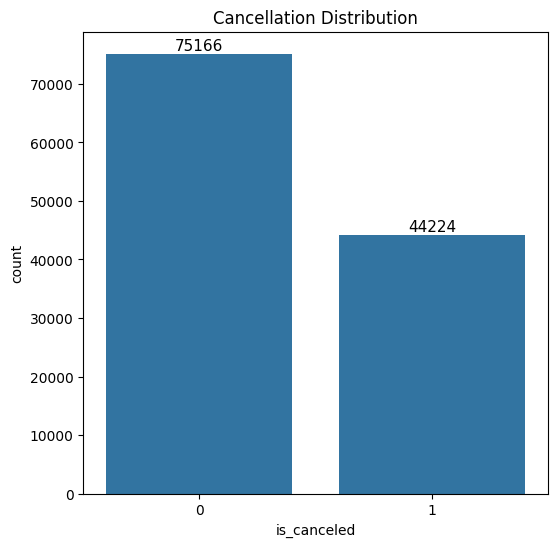

In [88]:
plt.figure(figsize=(6,6))

ax=sns.countplot(
    x="is_canceled",
    data=df
)

plt.title("Cancellation Distribution")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

The dataset shows that non-cancelled bookings are more frequent than cancelled bookings, indicating a moderate class imbalance.

##Numerical vs Categorical

In [89]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical Features:", len(num_cols))
print("Categorical Features:", len(cat_cols))

Numerical Features: 26
Categorical Features: 10


##Correlation Heatmap

<Axes: >

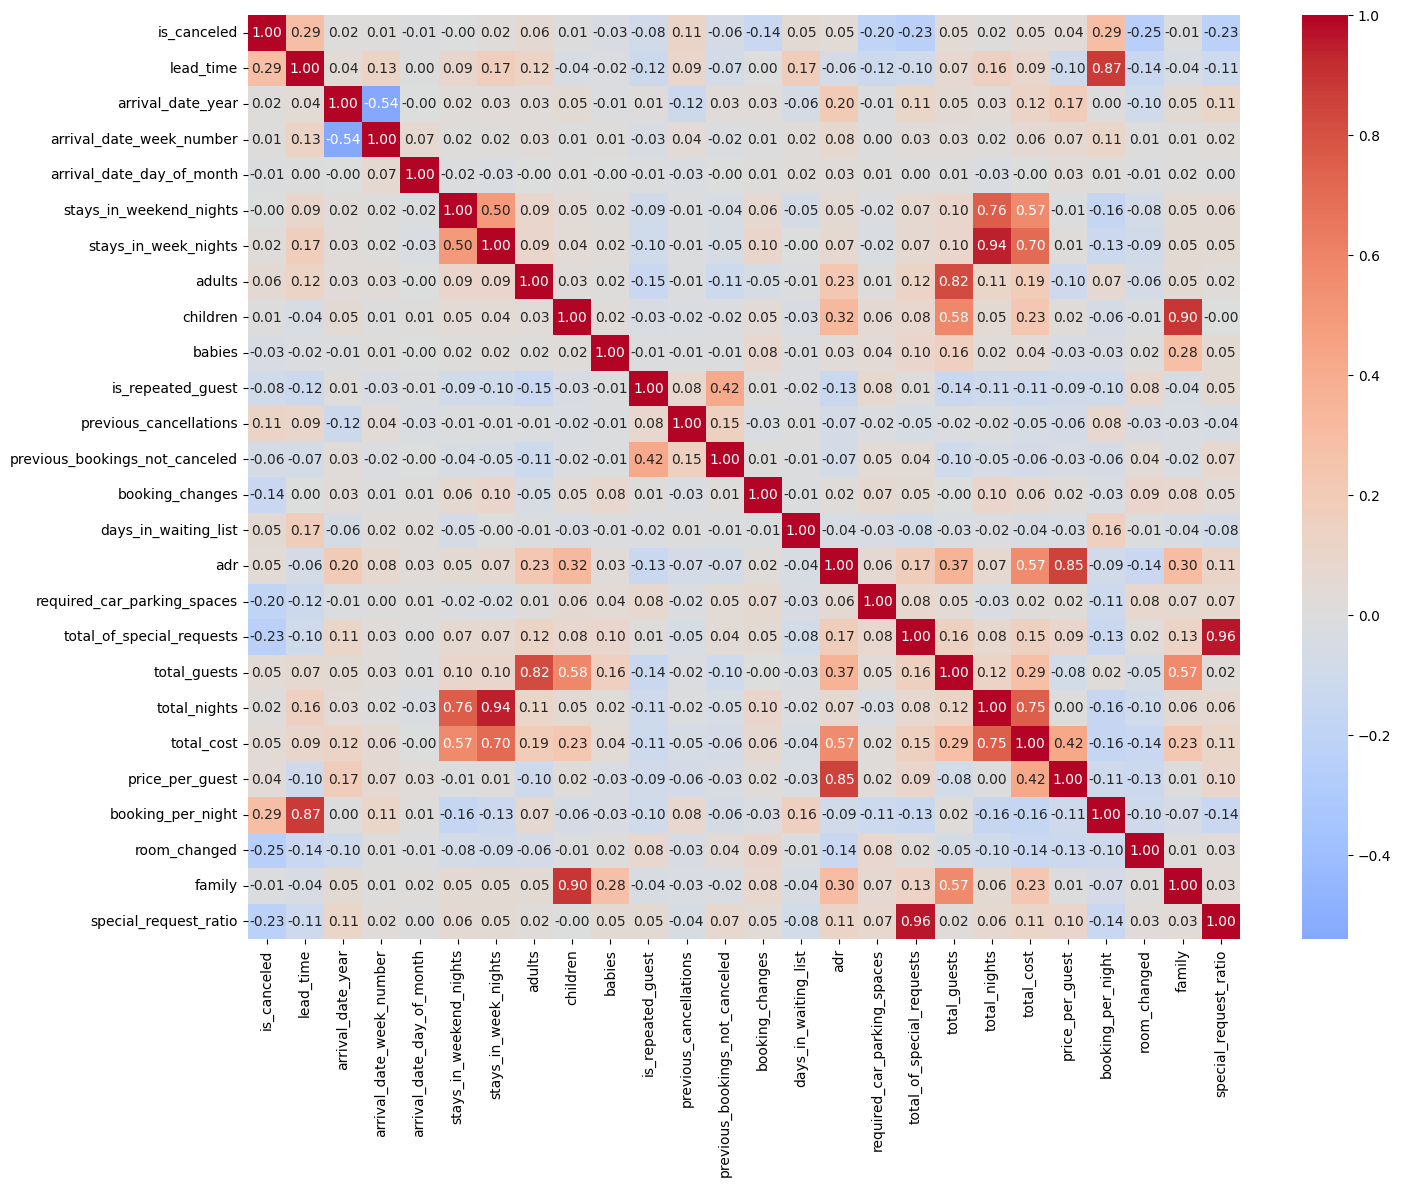

In [90]:
corr = df[num_cols].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

##Correlation with Target

In [91]:
corr_target = (
    df.corr(numeric_only=True)["is_canceled"]
    .sort_values(ascending=False)
)

corr_target

,is_canceled
is_canceled,1.000000
lead_time,0.293123
booking_per_night,0.291173
previous_cancellations,0.110133
adults,0.060017
days_in_waiting_list,0.054186
adr,0.047557
total_cost,0.046562
total_guests,0.046522
price_per_guest,0.036189


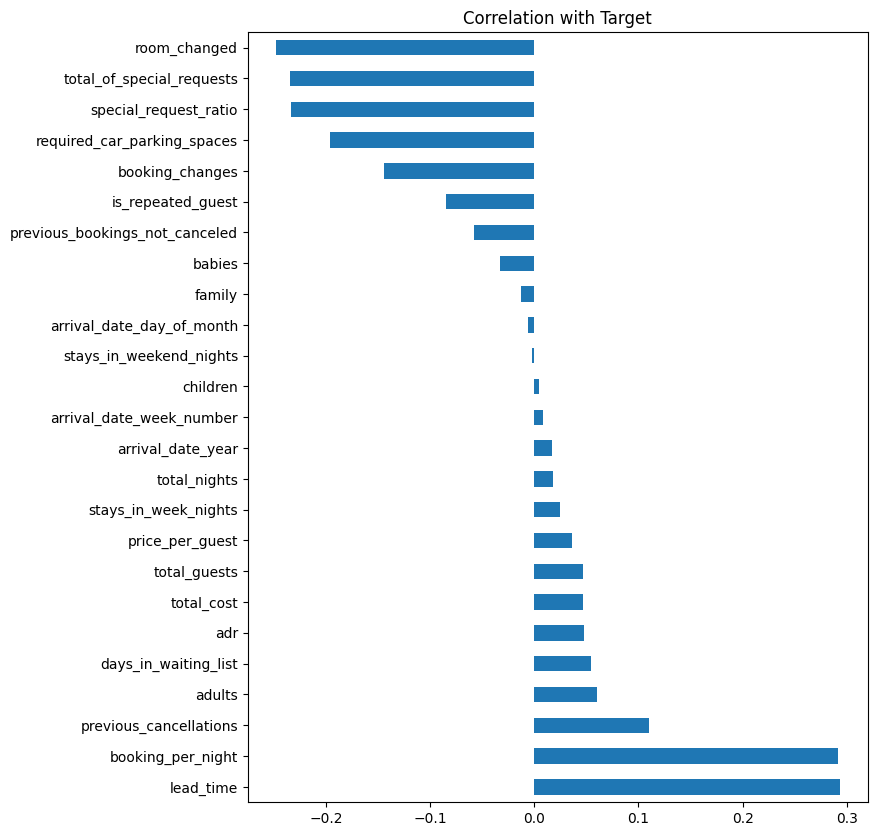

In [92]:
plt.figure(figsize=(8,10))

corr_target.drop("is_canceled").plot(kind="barh")

plt.title("Correlation with Target")

plt.show()

##Cancellation by Hotel Type

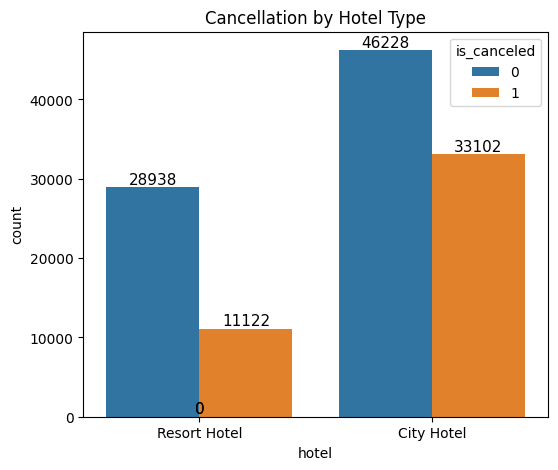

In [93]:
plt.figure(figsize=(6,5))

ax=sns.countplot(
    x="hotel",
    hue="is_canceled",
    data=df
)

plt.title("Cancellation by Hotel Type")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )


plt.show()

##Market Segment

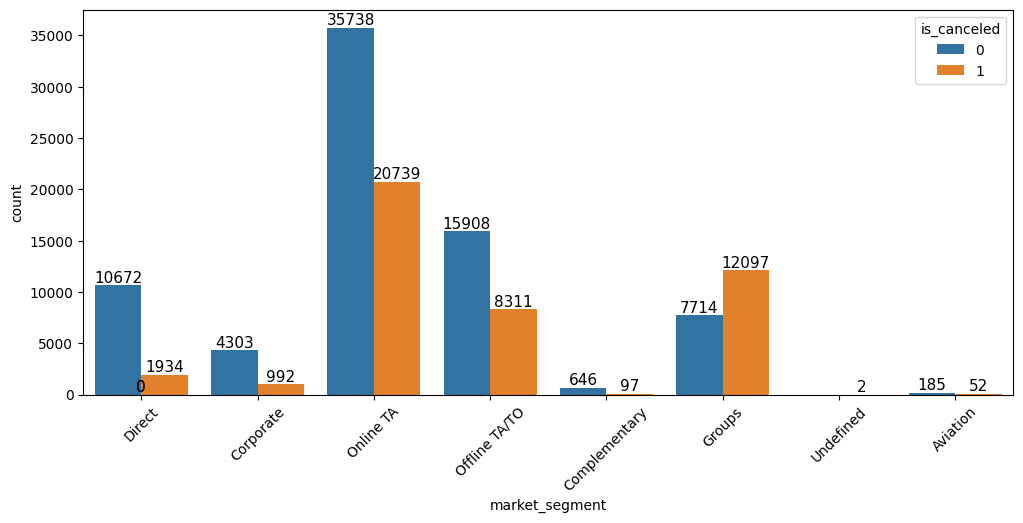

In [94]:
plt.figure(figsize=(12,5))

ax=sns.countplot(
    x="market_segment",
    hue="is_canceled",
    data=df
)

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

##Deposit Type

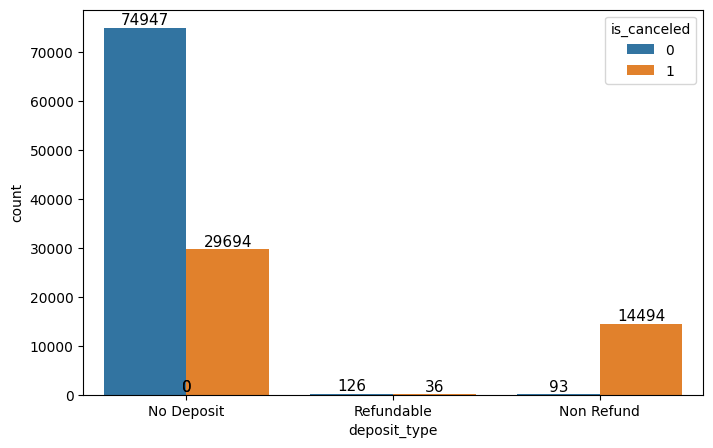

In [95]:
plt.figure(figsize=(8,5))

ax=sns.countplot(
    x="deposit_type",
    hue="is_canceled",
    data=df
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

##Customer Type

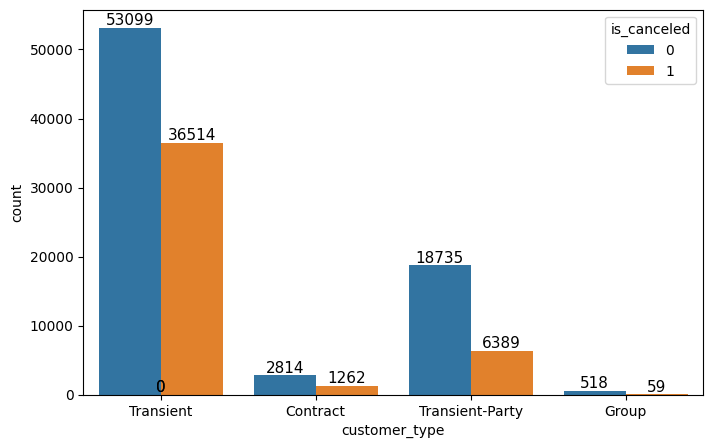

In [96]:
plt.figure(figsize=(8,5))

ax=sns.countplot(
    x="customer_type",
    hue="is_canceled",
    data=df
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

##Lead Time

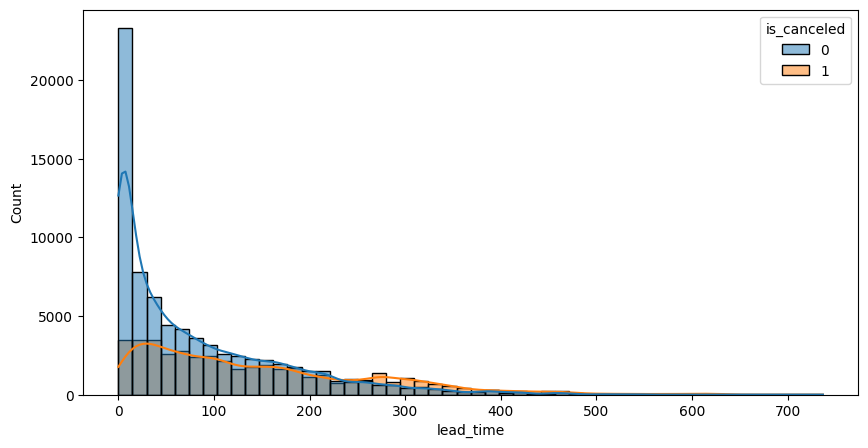

In [97]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="lead_time",
    hue="is_canceled",
    bins=50,
    kde=True
)

plt.show()

Bookings with longer lead times have a noticeably higher cancellation rate.

##ADR Distribution

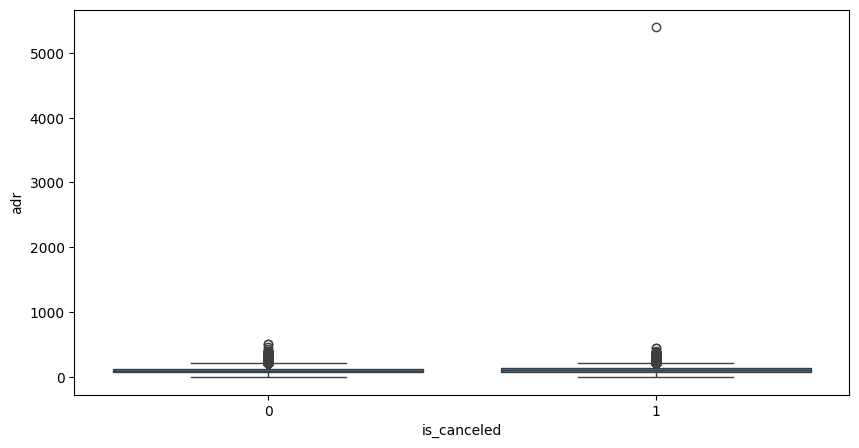

In [98]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="is_canceled",
    y="adr",
    data=df
)

plt.show()

##Month-wise Cancellation

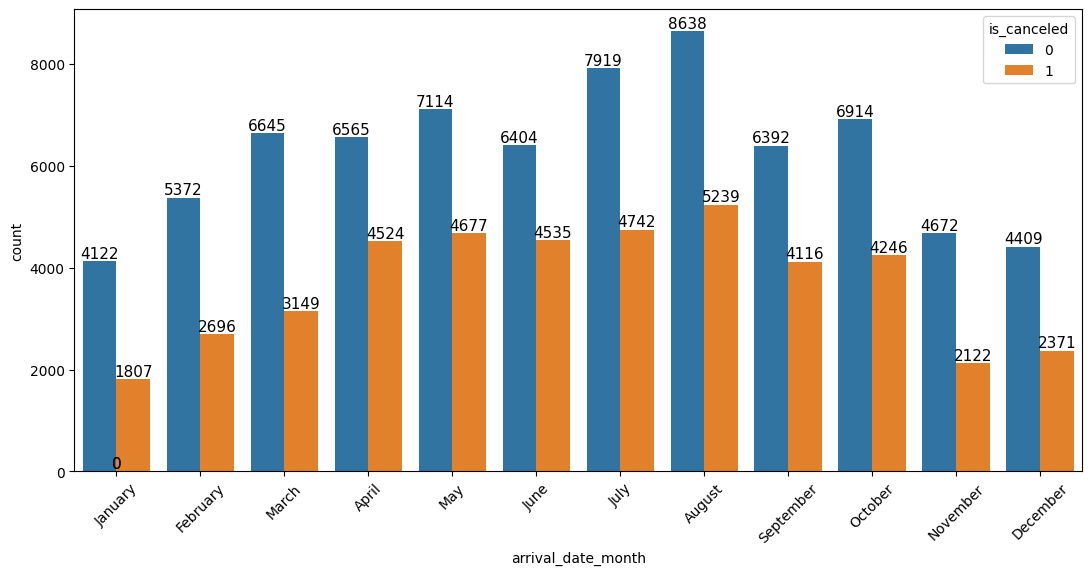

In [99]:
plt.figure(figsize=(13,6))

ax=sns.countplot(
    x="arrival_date_month",
    hue="is_canceled",
    data=df,
    order=[
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ]
)

plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )
plt.show()

##Country Analysis (Top 15)

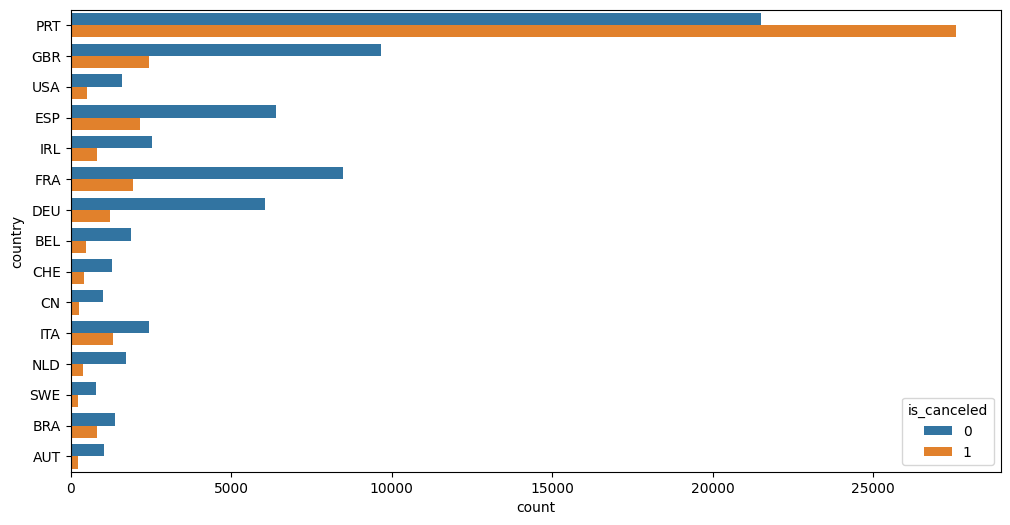

In [100]:
top_countries = df["country"].value_counts().head(15).index

plt.figure(figsize=(12,6))

sns.countplot(
    y="country",
    hue="is_canceled",
    data=df[df["country"].isin(top_countries)]
)

plt.show()

##Reserved vs Assigned Room

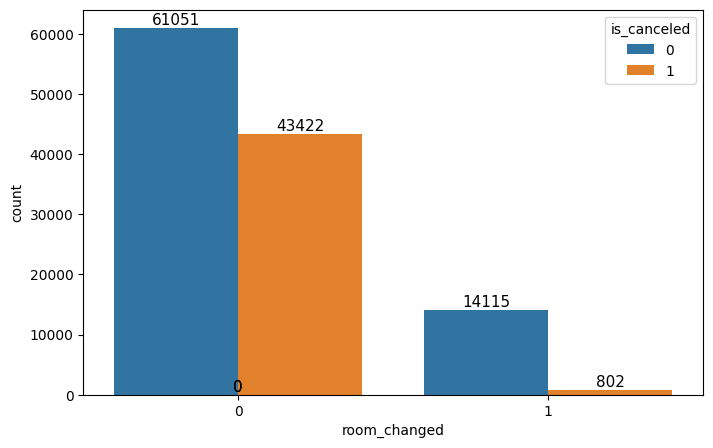

In [101]:
plt.figure(figsize=(8,5))

ax=sns.countplot(
    x="room_changed",
    hue="is_canceled",
    data=df
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

##Special Requests

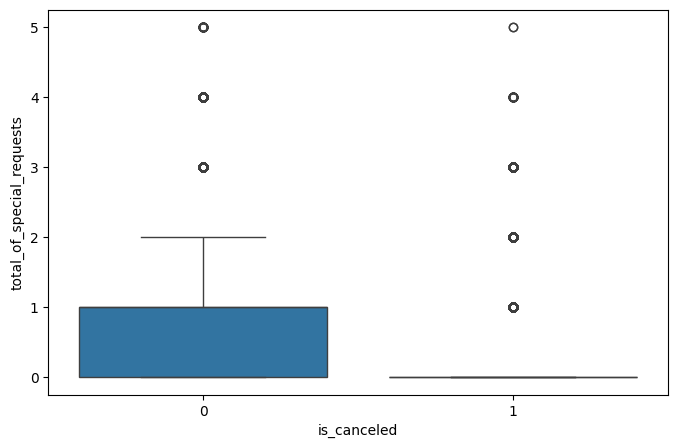

In [102]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="is_canceled",
    y="total_of_special_requests",
    data=df
)



plt.show()

##Total cost vs cancellation

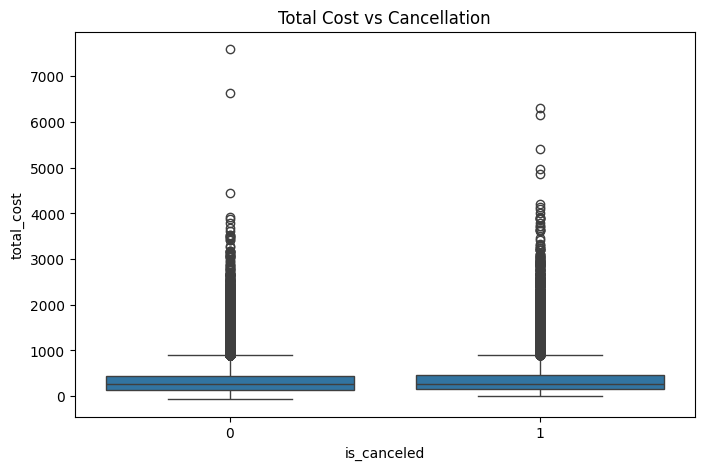

In [103]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_canceled",
    y="total_cost",
    data=df
)

plt.title("Total Cost vs Cancellation")
plt.show()

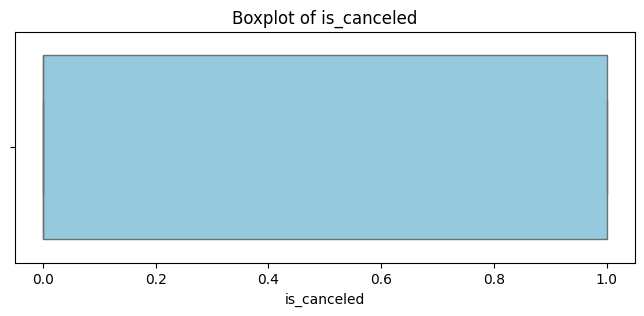

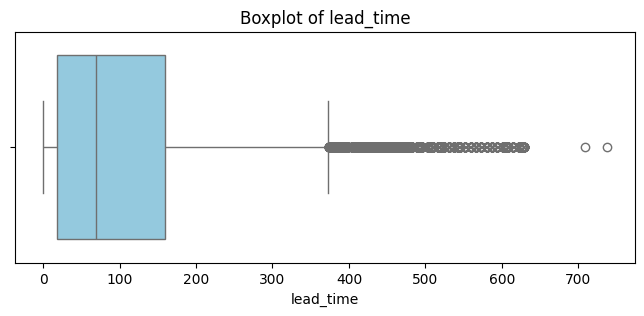

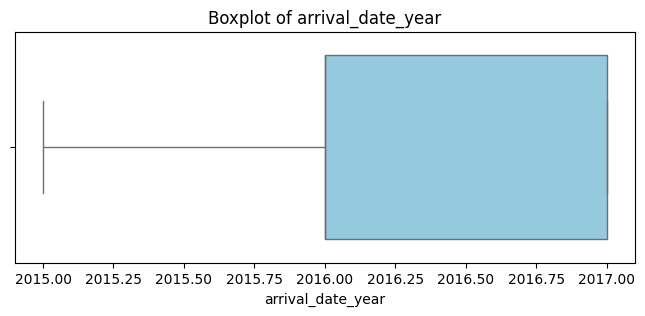

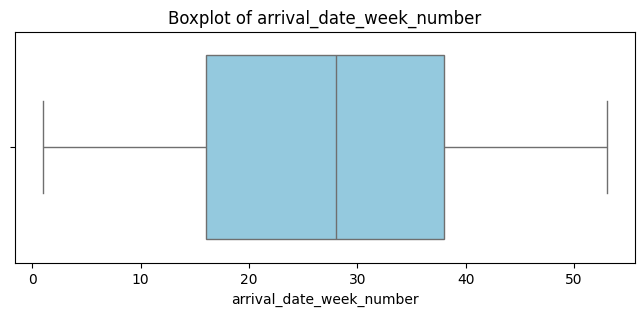

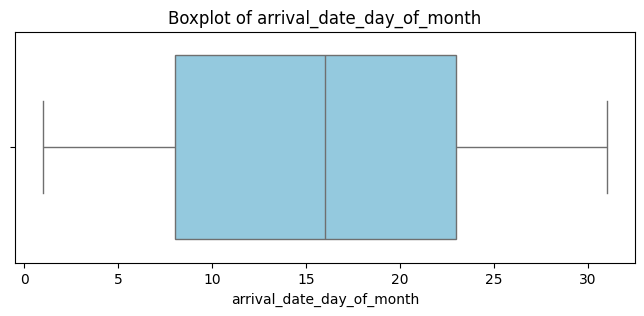

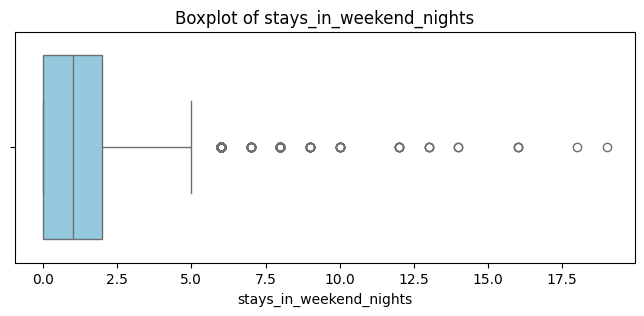

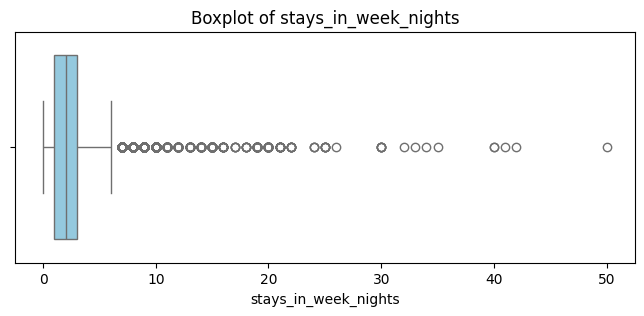

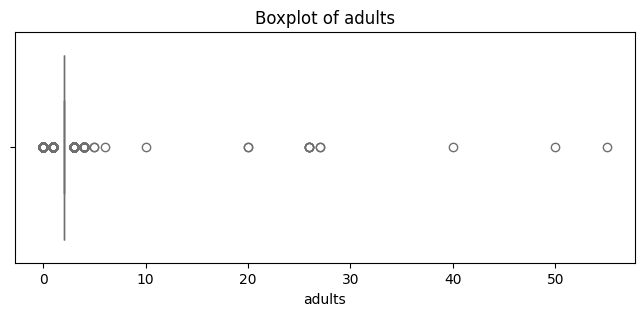

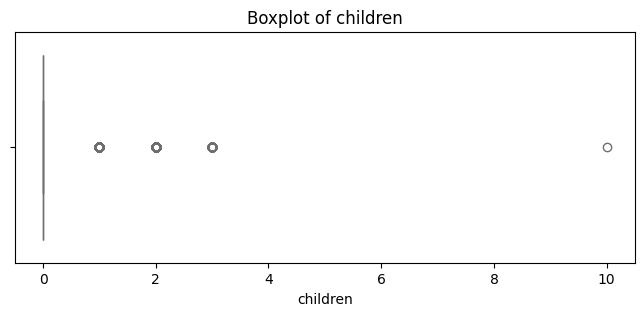

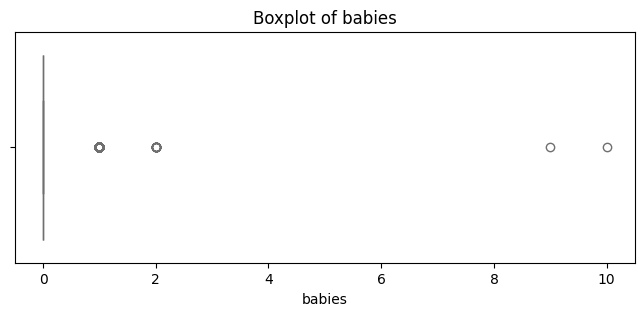

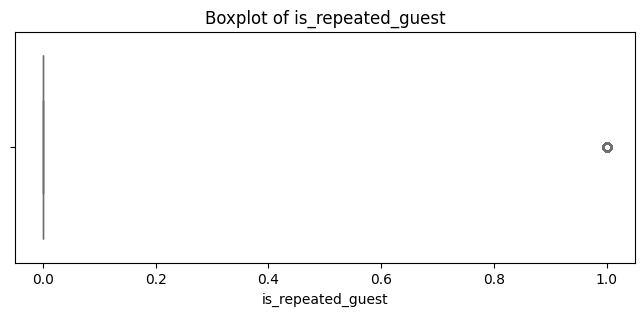

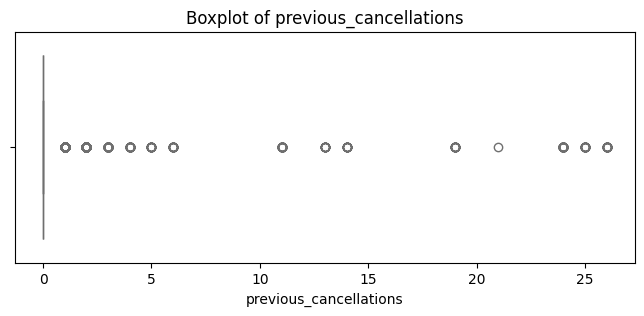

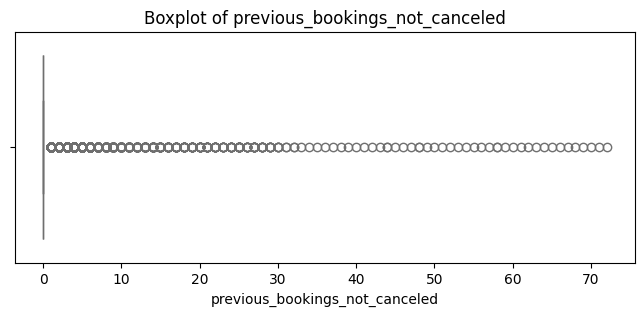

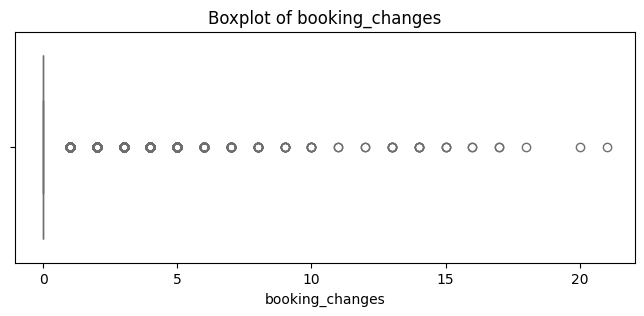

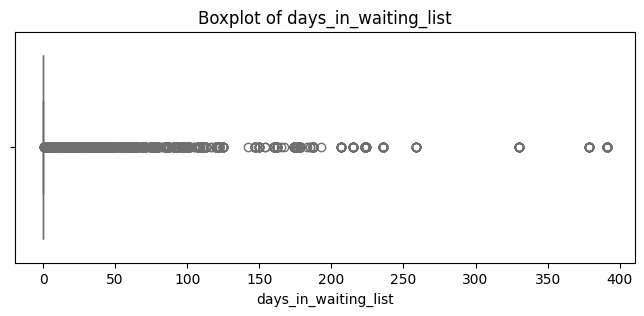

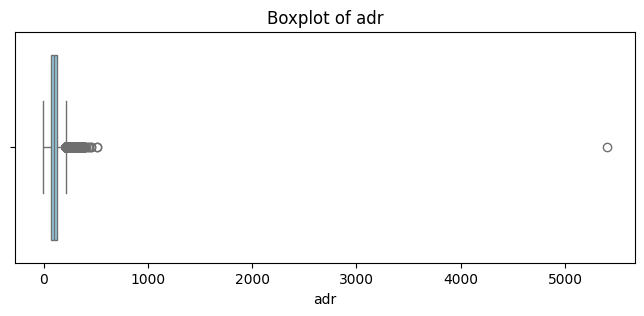

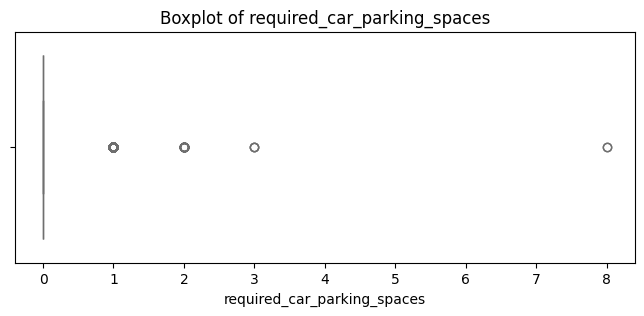

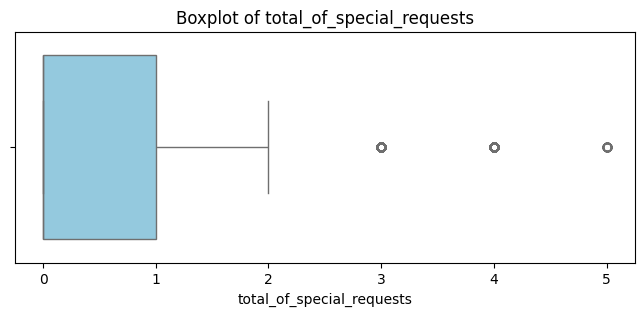

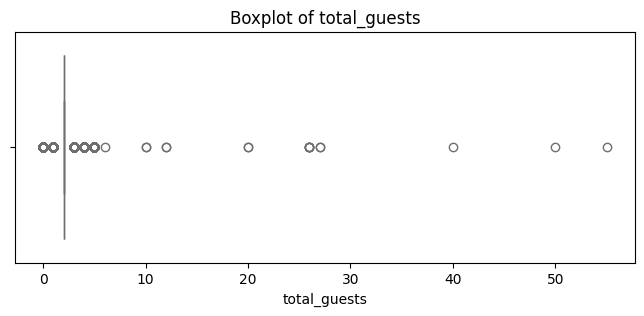

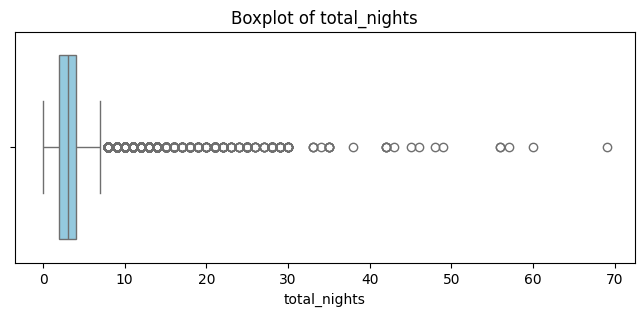

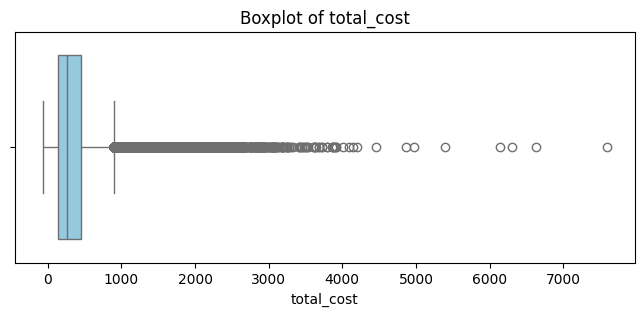

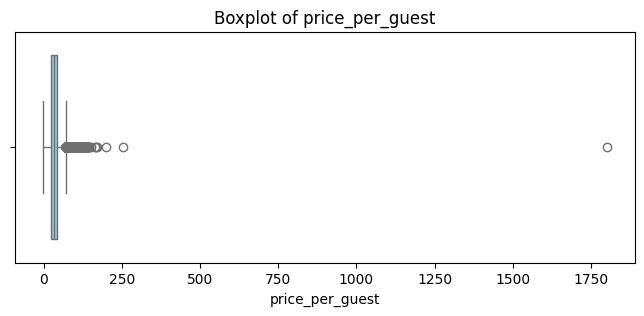

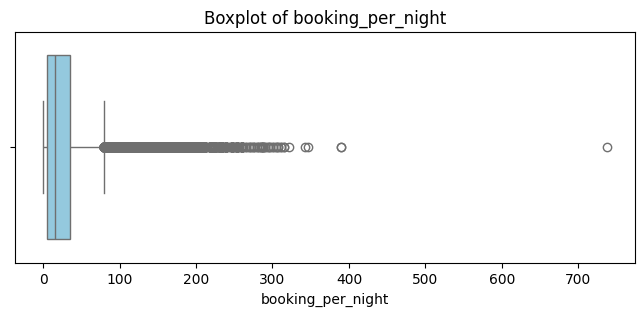

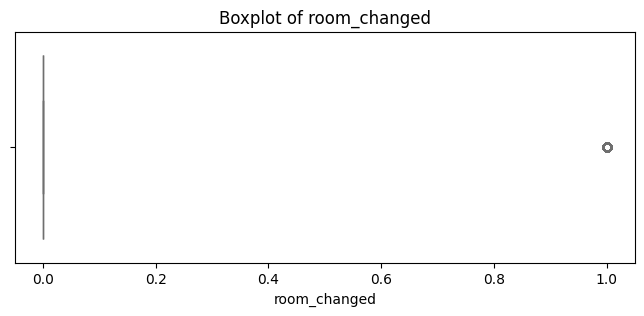

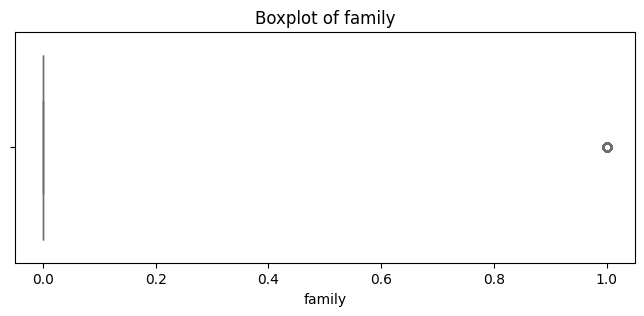

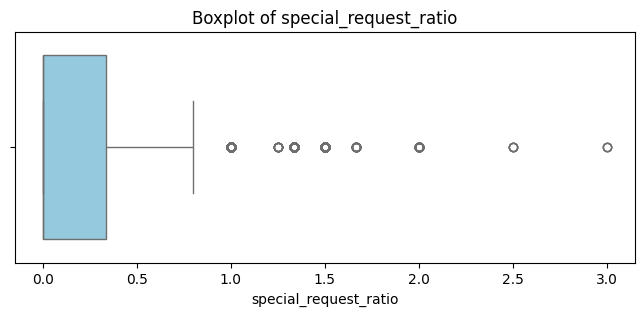

In [104]:
for col in num_cols:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col], color="skyblue")

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

In [105]:
outlier_summary = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values("Percentage", ascending=False)

,Feature,Outliers,Percentage
18,total_guests,37339,31.27
7,adults,29710,24.88
13,booking_changes,18076,15.14
23,room_changed,14917,12.49
24,family,9332,7.82
22,booking_per_night,8642,7.24
8,children,8590,7.19
20,total_cost,7692,6.44
16,required_car_parking_spaces,7416,6.21
11,previous_cancellations,6484,5.43


/tmp/ipykernel_9551/3262255854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


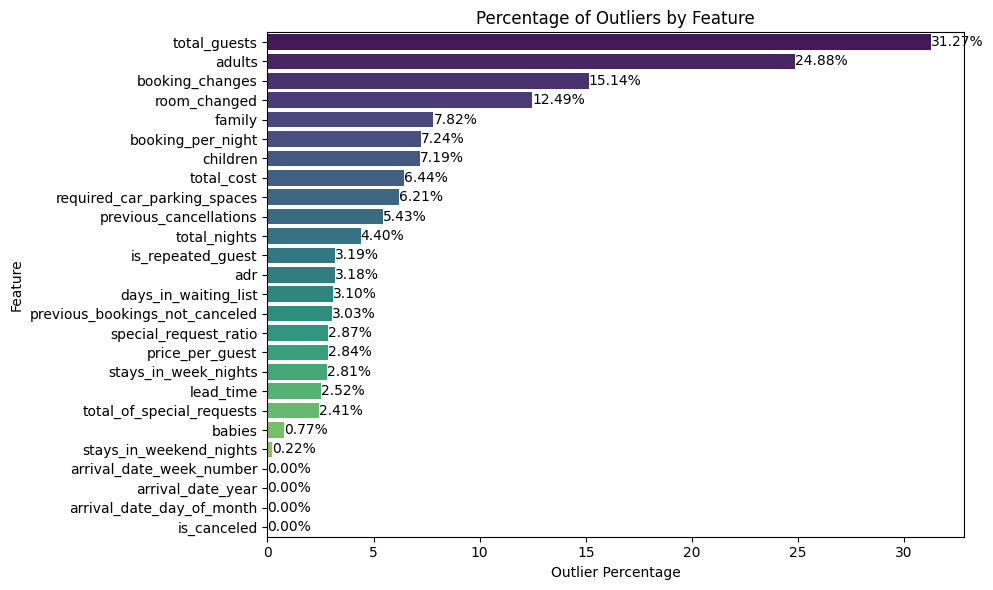

In [106]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=outlier_df.sort_values("Percentage", ascending=False),
    x="Percentage",
    y="Feature",
    palette="viridis"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}%",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha="left",
        va="center"
    )

plt.title("Percentage of Outliers by Feature")
plt.xlabel("Outlier Percentage")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

##Split Features & Target

In [107]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

##Train / Test Split

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (95512, 35)
Testing Shape : (23878, 35)


In [109]:
num_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", len(num_features))
print("Categorical:", len(cat_features))

Numerical: 25
Categorical: 10


In [110]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [111]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [112]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

In [113]:
X_train_processed = preprocessor.fit_transform(X_train)

print(X_train_processed.shape)

(95512, 258)


In [114]:
print(cat_features)

for col in cat_features:
    print(f"{col}: {df[col].nunique()}")

['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
hotel: 2
arrival_date_month: 12
meal: 5
country: 177
market_segment: 8
distribution_channel: 5
reserved_room_type: 10
assigned_room_type: 12
deposit_type: 3
customer_type: 4


In [115]:
print(X_train.shape)

(95512, 35)


#Build Pipeline

In [116]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),


    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_estimators=200,
            tree_method="hist",
            n_jobs=-1
        )
}


In [117]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
Accuracy : 0.8201691933997822
Precision: 0.8100558659217877
Recall   : 0.6721311475409836
F1 Score : 0.7346762234305487


In [118]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

In [119]:
print("Decision tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision tree
Accuracy : 0.8538403551386213
Precision: 0.8028503562945368
Recall   : 0.8024872809496891
F1 Score : 0.8026687775641751


In [120]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42,
         n_jobs=-1
     ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random forest
Accuracy : 0.8896892537063406
Precision: 0.8893067569261627
Recall   : 0.8020350480497456
F1 Score : 0.843419331827369


In [122]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         random_state=42,
         eval_metric="logloss",
         tree_method="hist",
         n_estimators=300,
         learning_rate=0.1,
         max_depth=6,
         n_jobs=-1
     ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

XGBoost
Accuracy : 0.873398107044141
Precision: 0.8533624666181112
Recall   : 0.79479932165065
F1 Score : 0.8230404495697478


In [133]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"


    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy


    ],

    "Precision":[
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision

    ],

    "Recall":[
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall


    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1


    ]

})

results = results.sort_values("F1 Score", ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.889689,0.889307,0.802035,0.843419
3,XGBoost,0.873398,0.853362,0.794799,0.823040
1,Decision Tree,0.853840,0.802850,0.802487,0.802669
0,Logistic Regression,0.820169,0.810056,0.672131,0.734676


/tmp/ipykernel_9551/2267964249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


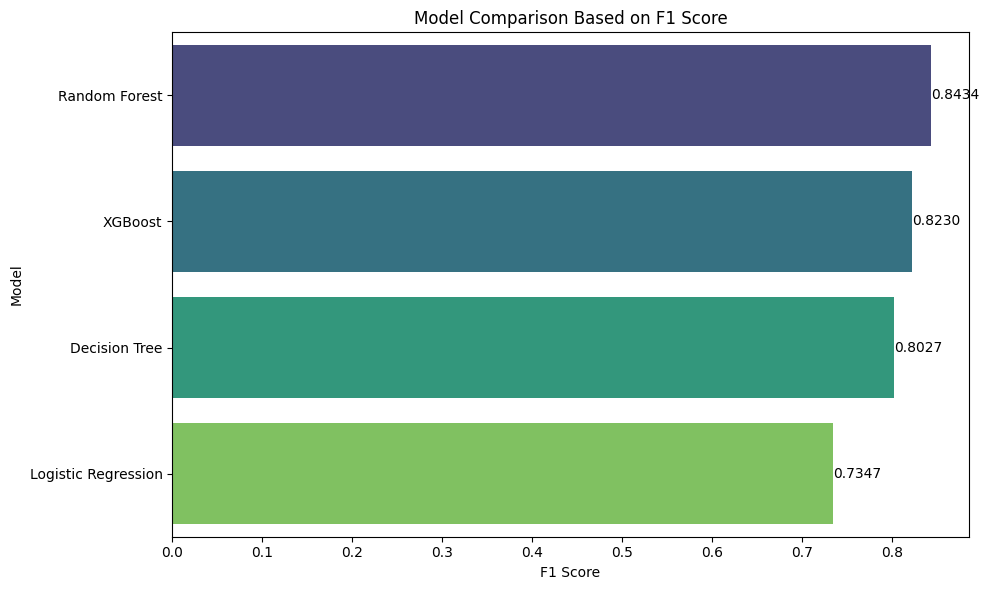

In [134]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=results,
    x="F1 Score",
    y="Model",
    palette="viridis"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.4f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha="left",
        va="center",
        fontsize=10
    )

plt.title("Model Comparison Based on F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

#Evaluation

              precision    recall  f1-score   support

Not Canceled       0.89      0.94      0.91     15033
    Canceled       0.89      0.80      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878



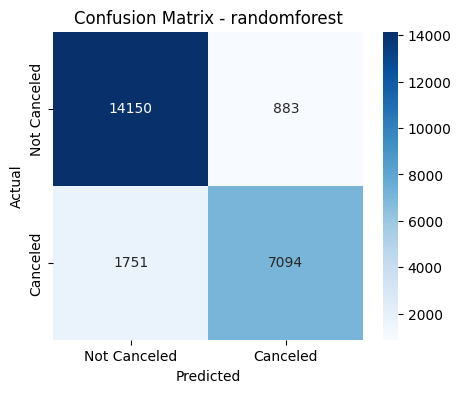

In [135]:


print(classification_report(y_test, rf_pred, target_names=["Not Canceled", "Canceled"]))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Canceled","Canceled"],
            yticklabels=["Not Canceled","Canceled"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - randomforest")
plt.show()

#Save Model

In [129]:
import joblib

joblib.dump(rf_pipeline, "hotel_booking_model.pkl")

['hotel_booking_model.pkl']

In [130]:
print(X.columns.tolist())

['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'total_cost', 'price_per_guest', 'booking_per_night', 'room_changed', 'family', 'special_request_ratio']


In [132]:
countries = sorted(df["country"].dropna().unique())

joblib.dump(countries,"countries.pkl")

['countries.pkl']

#Conclusion

This project developed a machine learning model to predict hotel booking cancellations using the Hotel Booking Demand dataset. The workflow followed a complete machine learning pipeline, beginning with data exploration and preprocessing, followed by feature engineering, model development, evaluation, hyperparameter tuning, threshold optimization, model persistence, and deployment preparation.

During preprocessing, missing values and duplicate records were handled appropriately, and categorical features were encoded using a preprocessing pipeline to prevent data leakage. Exploratory Data Analysis (EDA) provided valuable insights into booking patterns and highlighted the factors most associated with cancellations.

Several new features were engineered, including total guests, total nights, total cost, price per guest, booking per night, room changed, family, and special request ratio, allowing the models to capture more meaningful booking behavior than the original variables alone.

Multiple classification algorithms were trained and compared using Accuracy, Precision, Recall, and F1 Score, with particular emphasis on F1 Score because it is the evaluation metric of the competition.

The final optimized Random Forest model achieved the best performance among all evaluated models, making it a reliable solution for predicting hotel booking cancellations and supporting data-driven decision-making.